In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.shape

(5000, 13)

In [5]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

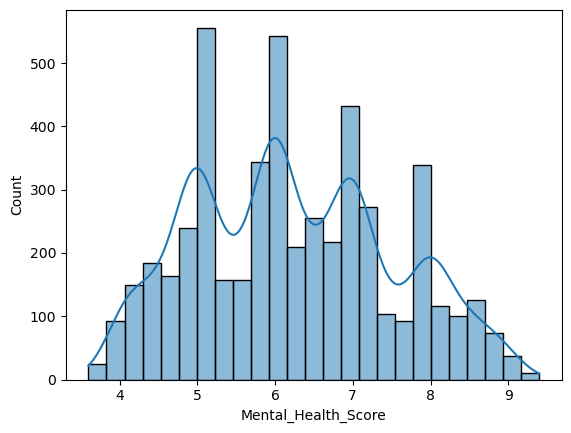

In [8]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

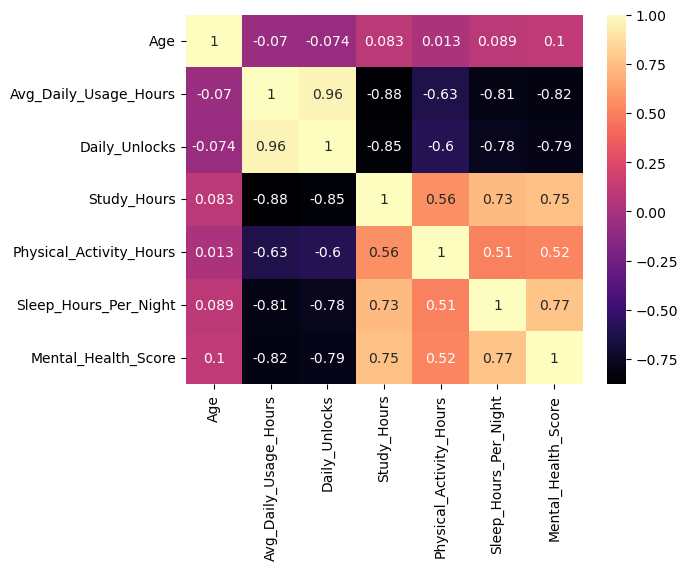

In [9]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='magma')

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

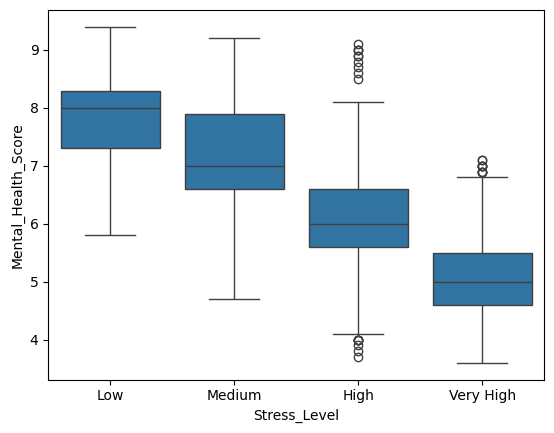

In [10]:
order=['Low','Medium','High','Very High']
sns.boxplot(data=df, y='Mental_Health_Score',x='Stress_Level',order=order)

<Axes: xlabel='Mental_Health_Score', ylabel='Avg_Daily_Usage_Hours'>

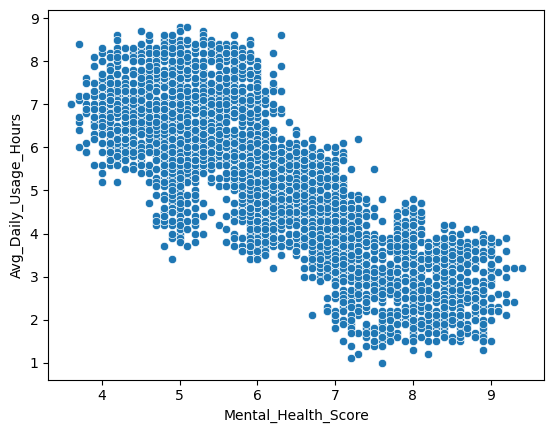

In [11]:
sns.scatterplot(data=df, x='Mental_Health_Score', y='Avg_Daily_Usage_Hours')

In [12]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


<Axes: xlabel='Mental_Health_Score', ylabel='Sleep_Hours_Per_Night'>

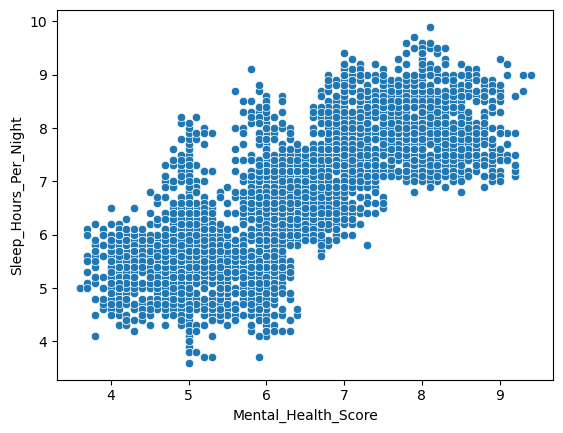

In [13]:
sns.scatterplot(data=df, x='Mental_Health_Score', y='Sleep_Hours_Per_Night')

In [14]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Facebook'),
  Text(1, 0, 'LinkedIn'),
  Text(2, 0, 'Instagram'),
  Text(3, 0, 'Snapchat'),
  Text(4, 0, 'Twitter'),
  Text(5, 0, 'YouTube'),
  Text(6, 0, 'TikTok'),
  Text(7, 0, 'LINE'),
  Text(8, 0, 'KakaoTalk'),
  Text(9, 0, 'VKontakte'),
  Text(10, 0, 'WhatsApp'),
  Text(11, 0, 'WeChat')])

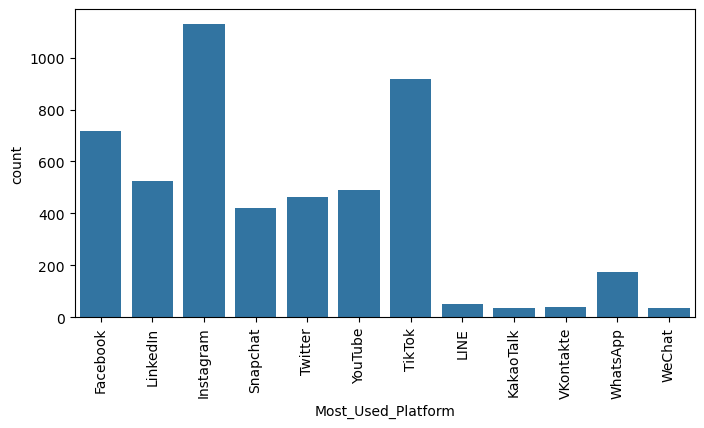

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Most_Used_Platform')
plt.xticks(rotation=90)

In [16]:


numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print(df.shape)

(4976, 13)


In [17]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000
mean,20.819735,5.080386,171.478497,3.004542,1.750000,6.634968,6.230225
std,1.737283,1.650060,42.793790,1.632927,0.657353,1.221737,1.277708
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.050000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.000000,3.500000,9.900000,9.400000


In [18]:
df[numeric_cols].skew()

Age                        0.156867
Avg_Daily_Usage_Hours      0.006152
Daily_Unlocks              0.001709
Study_Hours                0.428087
Physical_Activity_Hours    0.038402
Sleep_Hours_Per_Night      0.125622
Mental_Health_Score        0.208423
dtype: float64

In [19]:
'''skew near to 0 = centralized
negative= left skew
positive = right skew'''


'skew near to 0 = centralized\nnegative= left skew\npositive = right skew'

In [20]:
df['Country'].nunique()

111

In [21]:
top_countries=df['Country'].value_counts().index[:10].tolist()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [22]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'


In [23]:
group_countries('afganisthan')

'Other'

In [24]:
df['grouped_country']=df['Country'].apply(group_countries)

In [25]:
df['grouped_country'].value_counts()

grouped_country
Other        3212
India         386
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [26]:
df['Country'].value_counts()

Country
Other        1865
India         386
USA           354
Canada        230
Australia     198
             ... 
Armenia         1
Kuwait          1
Colombia        1
Bosnia          1
Croatia         1
Name: count, Length: 111, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split

skwewd_col         = ['Study_Hours']#log transformation
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]#standardscaling
ordinal_col        = ['Stress_Level']#ordinal encoding wale
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "grouped_country"] #one hot encoding wale


feature_col = skwewd_col + other_numeric_cols + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer

In [29]:
#1.skewed_features
skew_pipeline=Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])
#2. numerical_features
numerical_pipeline=Pipeline(steps=[
    ('scale',StandardScaler())
])
#3. ordinal_features
ordinal_pipeline=Pipeline(steps=[
    ('ordinal_encoder',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])
#4. one hot encoder
one_hot_pipeline=Pipeline(steps=[
    ('one_hot_encoder',OneHotEncoder(handle_unknown='ignore'))
])
#konsi pipeline konsa feature
preprocessor=ColumnTransformer([
    ('skew_pipeline',skew_pipeline,skwewd_col),
    ('Plain_mumeric',numerical_pipeline,other_numeric_cols),
    ("ordinal",ordinal_pipeline,ordinal_col),
    ('Normal',one_hot_pipeline,normal_col)

])

In [30]:
from sklearn.linear_model import LinearRegression
model_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])
model_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Study_Hours','Age','Avg_Daily_Usage_Hours',...,'Most_Used_Platform', 'Purpose_Of_Use','grouped_country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew_pipeline', ...), ('Plain_mumeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `f

In [31]:
y_pred_test=model_pipeline.predict(X_test)
y_pred_train=model_pipeline.predict(X_train)


In [32]:
print(y_pred_test)
print(y_pred_train)

[7.57738892 5.19377946 5.38256003 ... 4.6025191  6.04274685 6.48541416]
[8.26098622 6.89388965 6.38874421 ... 4.74165516 4.55050271 5.19747698]


In [33]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
acc_test=r2_score(y_test,y_pred_test)
acc_train=r2_score(y_train,y_pred_train)
mae=mean_absolute_error(y_test,y_pred_test)
print("acc=",acc_test)
print("acc_train=",acc_train)
print("mae=",mae)
print("mse=",mean_squared_error(y_test,y_pred_test))
print("rmse=",np.sqrt(mean_squared_error(y_test,y_pred_test)))

acc= 0.7308171179057356
acc_train= 0.727010443221618
mae= 0.5255384257810459
mse= 0.445205459492344
rmse= 0.6672371838352117


In [34]:
from sklearn.ensemble import RandomForestRegressor
model2_pipeline=Pipeline(steps=[
    ('processor',preprocessor),
    ('regressor',RandomForestRegressor(random_state=42))
])
model2_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Study_Hours','Age','Avg_Daily_Usage_Hours',...,'Most_Used_Platform', 'Purpose_Of_Use','grouped_country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew_pipeline', ...), ('Plain_mumeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit`

In [35]:
y_pred2_testing=model2_pipeline.predict(X_test)
y_pred2_training=model2_pipeline.predict(X_train)

In [36]:
print(y_pred2_testing)
print(y_pred2_training)

[7.915 5.354 5.052 ... 4.782 6.179 6.394]
[8.029 5.54  6.772 ... 5.034 5.005 5.678]


In [37]:
accu_test=r2_score(y_test,y_pred2_testing)
accu_train=r2_score(y_train,y_pred2_training)
mae2=mean_absolute_error(y_test,y_pred2_testing)
print("acc_test_rf=",accu_test)
print("acc_train_rf=",accu_train)
print("mae=",mae2)

acc_test_rf= 0.8784951041863491
acc_train_rf= 0.9812905428879438
mae= 0.3306491962491629


In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'regressor__n_estimators'       : [100,200,300],
    'regressor__max_depth'         : [5,10,15],
    'regressor__min_samples_split' : [2,5,10],
    'regressor__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=model2_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [5, 10, ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], 'regressor__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Ra

In [39]:
random_search.best_params_

{'regressor__n_estimators': 300,
 'regressor__min_samples_split': 5,
 'regressor__min_samples_leaf': 2,
 'regressor__max_depth': 15}

In [40]:
model2_best_pipeline = random_search.best_estimator_
model2_best_preds    = model2_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, model2_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, model2_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8682575197200003
MAE Score for random forest after hyperparameter tuning 0.34921116962213217


In [41]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
model_rmse = np.sqrt(mean_squared_error(y_test,y_pred_test))

# Calculate RMSE for default Random Forest
model2_rmse = np.sqrt(mean_squared_error(y_test, y_pred2_testing))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [acc_test, accu_test, rf_tuned_r2],
    'Training R2': [acc_train, accu_train, r2_tuned_training],
    'MAE': [mae, mae2, rf_tuned_mae],
    'RMSE': [model_rmse, model2_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.730817     0.727010  0.525538  0.667237
1  Random Forest (default)  0.878495     0.981291  0.330649  0.448284
2    Random Forest (tuned)  0.868258     0.956304  0.349211  0.466788


In [42]:
import joblib
joblib.dump(model2_best_pipeline, 'Mental_Health_Model.pkl')


['Mental_Health_Model.pkl']

In [43]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'grouped_country']

In [44]:
df['Most_Used_Platform'].unique().tolist()


['Facebook',
 'LinkedIn',
 'Instagram',
 'Snapchat',
 'Twitter',
 'YouTube',
 'TikTok',
 'LINE',
 'KakaoTalk',
 'VKontakte',
 'WhatsApp',
 'WeChat']